In [1]:
from google.colab import files

uploaded = files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

  crop_type soil_type  yield_ton_per_hectare  
0     Maize     Loamy                   5.92  
1     Maize     Sandy                   6.24  
2     Wheat     Sandy                   4.77  
3     Maize     Loamy                   4.04  
4    Cotton      Clay                   5.17  


In [3]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))

Rows and Columns:
(1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3            

In [4]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [5]:
stats = df.describe()

print(stats)

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

In [6]:
print(stats.loc['mean'].idxmax())

rainfall_mm


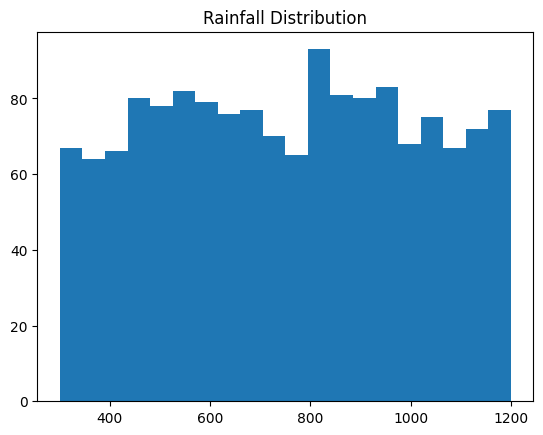

In [8]:
plt.hist(df['rainfall_mm'], bins=20)
plt.title("Rainfall Distribution")
plt.show()

In [9]:
print(df['crop_type'].value_counts())

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


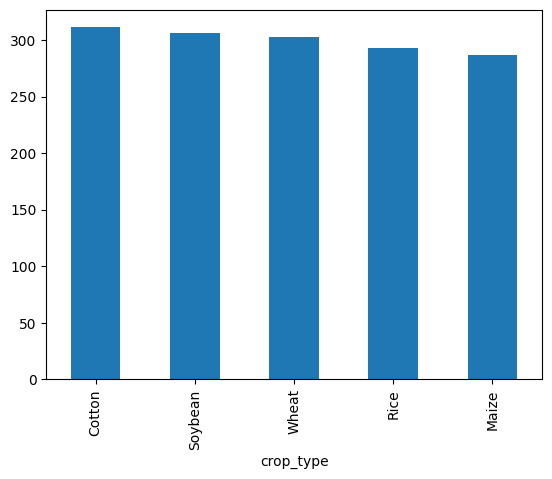

In [10]:
df['crop_type'].value_counts().plot(kind='bar')
plt.show()

In [11]:
print(df['soil_type'].mode()[0])

Clay


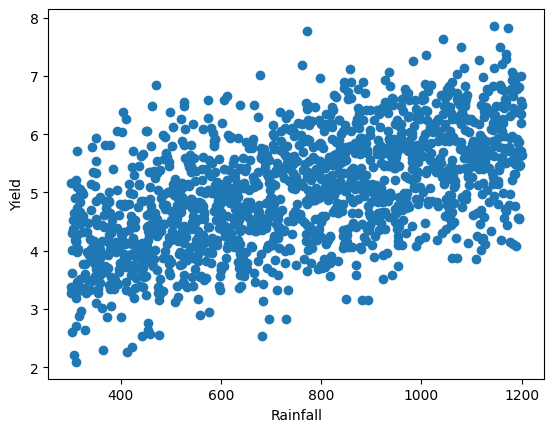

In [12]:
plt.scatter(
    df['rainfall_mm'],
    df['yield_ton_per_hectare']
)
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

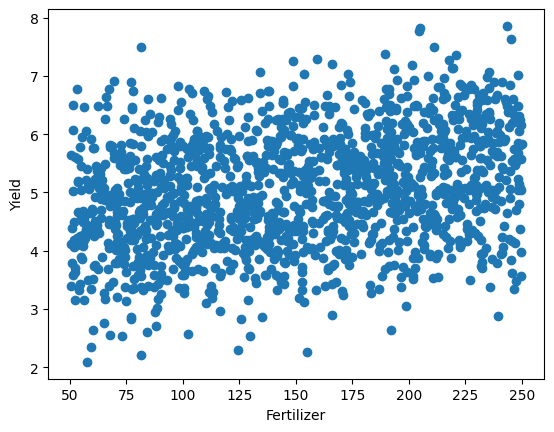

In [13]:
plt.scatter(
    df['fertilizer_kg'],
    df['yield_ton_per_hectare']
)
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

In [14]:
corr = df.corr(numeric_only=True)

print(corr)

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

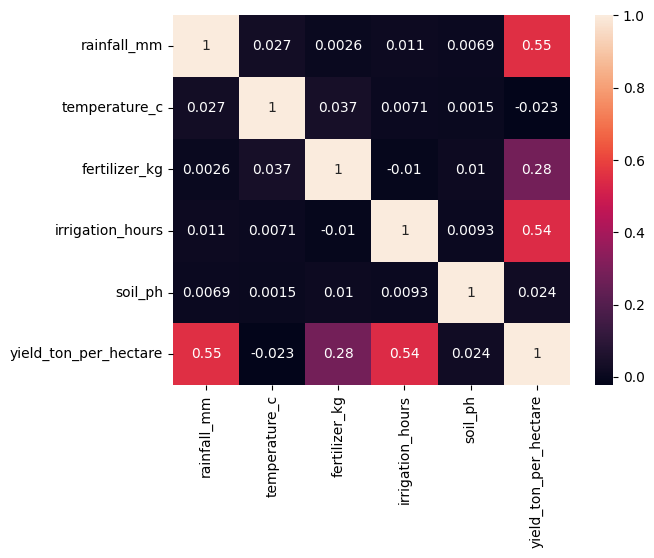

In [15]:
sns.heatmap(corr, annot=True)
plt.show()

In [16]:
crop_avg = df.groupby(
    'crop_type'
)['yield_ton_per_hectare'].mean()

print(crop_avg)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


In [17]:
soil_avg = df.groupby(
    'soil_type'
)['yield_ton_per_hectare'].mean()

print(soil_avg)

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [18]:
df_encoded = pd.get_dummies(
    df,
    columns=['crop_type', 'soil_type'],
    drop_first=True
)

print(df_encoded.shape)
df_encoded.head()

(1500, 12)


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [19]:
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

y = df_encoded['yield_ton_per_hectare']

print(X.shape)
print(y.shape)

(1500, 11)
(1500,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1200, 11)
(300, 11)
(1200,)
(300,)


In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

Intercept:
1.587132027736121


In [22]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(coef_df)

              Feature  Coefficient
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
5     crop_type_Maize     0.238931
3    irrigation_hours     0.198327
2       fertilizer_kg     0.004978
4             soil_ph     0.004901
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
10    soil_type_Sandy    -0.490933


In [23]:
print(coef_df.iloc[0])

Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
